# ZWO Camera Timing Analysis

Analyses the frame-delivery timing of a ZWO sCMOS camera driven by MicroManager.
A triangle-wave illumination signal of known frequency is recorded alongside
per-frame timestamps; the notebook reconstructs the waveform from frame intensities
and characterises host-side delivery jitter.

In [1]:
import sys
sys.path.append("../..")

from src import IOFunctions, PlottingBase

import os
import re
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

IO = IOFunctions.IO_Functions()
plotter = PlottingBase.PublicationPlotter()

In [2]:
DATA_DIR = "/media/jbeckwith/JSB_BACKUP_01/ZWO_Timing/1HzTri_10ms_512x512px/Pos-0-0"

## 1. Load data

In [3]:
folder_name = os.path.basename(os.path.dirname(DATA_DIR))
m = re.match(r'(\d+)HzTri_(\d+)ms_(\d+)x(\d+)px', folder_name)
freq_hz          = float(m.group(1))
nominal_frame_ms = float(m.group(2))
width, height    = int(m.group(3)), int(m.group(4))

ts = pd.read_csv(os.path.join(DATA_DIR, "timestamps.csv"))

# Sort TIFF files so multi-file datasets concatenate in frame order.
# Pos-0-0_MMStack.ome.tif  →  index 0
# Pos-0-0_MMStack_1.ome.tif → index 1, etc.
def _tif_sort_key(path):
    m2 = re.search(r'MMStack(?:_(\d+))?\.ome\.tif$', os.path.basename(path))
    return int(m2.group(1)) if m2 and m2.group(1) else 0

tif_files = sorted(
    glob.glob(os.path.join(DATA_DIR, "Pos-0-0_MMStack*.ome.tif")),
    key=_tif_sort_key,
)

stacks = [IO.read_tiff(f, dtype="float32", memmap=True) for f in tif_files]
stack  = np.concatenate(stacks, axis=0) if len(stacks) > 1 else stacks[0]
frame_sums = stack.sum(axis=(1, 2))
del stack, stacks

print(f"Dataset:            {folder_name}")
print(f"Input signal:       {freq_hz:.0f} Hz triangle wave")
print(f"Nominal frame time: {nominal_frame_ms:.0f} ms  ({1000/nominal_frame_ms:.0f} fps)")
print(f"Resolution:         {width}\u00d7{height} px")
print(f"Total frames:       {len(ts)}")
print(f"Total duration:     {ts['camera_elapsed_ms'].iloc[-1]/1000:.2f} s")

Dataset:            1HzTri_10ms_512x512px
Input signal:       1 Hz triangle wave
Nominal frame time: 10 ms  (100 fps)
Resolution:         512×512 px
Total frames:       5000
Total duration:     50.40 s


## 2. Triangle wave recovery

Summing all pixels per frame gives a proxy for total illumination.  
Plotted against the camera's elapsed-time column this should trace a 1 Hz triangle wave.

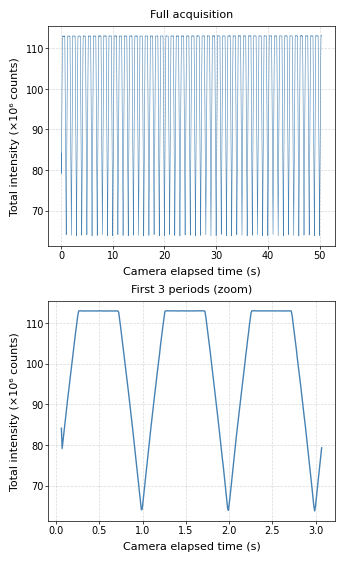

In [4]:
t_cam_s = ts["camera_elapsed_ms"].values * 1e-3

fig, axs = plotter.one_column_plot(npanels=2, ratios=[1, 1], height=5.5)

plotter.line_plot(
    axs[0], t_cam_s, frame_sums * 1e-6,
    xlabel="Camera elapsed time (s)",
    ylabel="Total intensity (\u00d710\u2076 counts)",
    color="steelblue", linewidth=0.4,
)

n_zoom = int(np.ceil(3.0 / (nominal_frame_ms * 1e-3)))
plotter.line_plot(
    axs[1], t_cam_s[:n_zoom], frame_sums[:n_zoom] * 1e-6,
    xlabel="Camera elapsed time (s)",
    ylabel="Total intensity (\u00d710\u2076 counts)",
    color="steelblue", linewidth=1.0,
)
axs[0].set_title("Full acquisition", fontsize=8)
axs[1].set_title("First 3 periods (zoom)", fontsize=8)

plotter.save_or_show(fig)

### 2a. Waveform fit

The raw trace reveals that the lamp saturates at its maximum output: a large flat-top
region occupies roughly half of each period, with a sharp triangular trough below.

**Model — clipped triangle wave:**

$$I(t) = \min\!\Bigl(A \cdot \tfrac{2}{\pi} \arcsin\!\bigl(\sin(2\pi f t + \varphi)\bigr) + B,\; I_\text{clip}\Bigr)$$

Parameters: underlying half-amplitude $A$, frequency $f$, phase $\varphi$, DC offset $B$,
and saturation ceiling $I_\text{clip}$.

Initial phase is estimated from the first trough (unambiguous in the data);
initial amplitude and offset are derived from the measured trough depth and flat-top fraction.

In [5]:
def clipped_triangle_model(t, A, f, phi, offset, clip_level):
    """Triangle wave (arcsin form) hard-clipped from above at clip_level."""
    tri = A * (2.0 / np.pi) * np.arcsin(np.sin(2.0 * np.pi * f * t + phi)) + offset
    return np.minimum(tri, clip_level)

# --- initial parameter estimates ---
# Robust extrema (percentile avoids single-frame outliers)
clip0   = float(np.percentile(frame_sums, 99.5))
trough0 = float(np.percentile(frame_sums,  0.5))

# Fraction of frames on the flat top → cos(flat_frac·π) gives the normalised
# clipping threshold of the underlying triangle.
flat_frac   = float((frame_sums > clip0 * 0.9995).mean())
T_clip_norm = np.cos(flat_frac * np.pi) if flat_frac > 0 else 0.0
A0          = (clip0 - trough0) / (1.0 + T_clip_norm)
offset0     = trough0 + A0

# Phase from first trough: tri = −1 when its argument = −π/2
n_search = int(2.0 / (nominal_frame_ms * 1e-3))
idx_min  = int(np.argmin(frame_sums[:n_search]))
phi0     = -np.pi / 2.0 - 2.0 * np.pi * freq_hz * t_cam_s[idx_min]
phi0     = (phi0 + np.pi) % (2.0 * np.pi) - np.pi  # wrap to [−π, π]

p0 = [A0, freq_hz, phi0, offset0, clip0]

popt, pcov = optimize.curve_fit(
    clipped_triangle_model, t_cam_s, frame_sums, p0=p0, maxfev=20_000
)
perr = np.sqrt(np.diag(pcov))
A_fit, f_fit, phi_fit, offset_fit, clip_fit = popt

fit_vals  = clipped_triangle_model(t_cam_s, *popt)
residuals = frame_sums - fit_vals

fitted_flat_frac = float((frame_sums > clip_fit * 0.9995).mean())

print(f"Clipped triangle wave fit results")
print(f"  Fitted frequency   : {f_fit:.6f} ± {perr[1]:.6f} Hz  (nominal {freq_hz:.1f} Hz)")
print(f"  Frequency error    : {abs(f_fit - freq_hz) / freq_hz * 100:.4f} %")
print(f"  Half-amplitude (A) : {A_fit*1e-6:.3f} ×10⁶ counts")
print(f"  DC offset (B)      : {offset_fit*1e-6:.3f} ×10⁶ counts")
print(f"  Saturation ceiling : {clip_fit*1e-6:.3f} ×10⁶ counts")
print(f"  Predicted trough   : {(offset_fit-A_fit)*1e-6:.3f} ×10⁶ counts  (actual min: {frame_sums.min()*1e-6:.3f})")
print(f"  Flat-top fraction  : {fitted_flat_frac:.3f} of each period")
print(f"  Residual std       : {residuals.std()*1e-6:.4f} ×10⁶ counts  ({residuals.std()/abs(A_fit)*100:.2f}% of amplitude)")

Clipped triangle wave fit results
  Fitted frequency   : 0.999981 ± 0.000002 Hz  (nominal 1.0 Hz)
  Frequency error    : 0.0019 %
  Half-amplitude (A) : 46.786 ×10⁶ counts
  DC offset (B)      : 110.767 ×10⁶ counts
  Saturation ceiling : 113.028 ×10⁶ counts
  Predicted trough   : 63.981 ×10⁶ counts  (actual min: 63.747)
  Flat-top fraction  : 0.460 of each period
  Residual std       : 0.3145 ×10⁶ counts  (0.67% of amplitude)


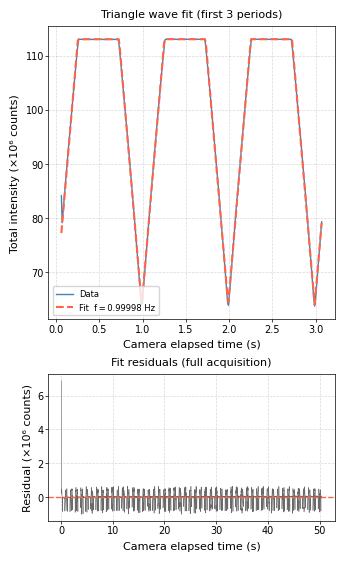

In [6]:
fig, axs = plotter.one_column_plot(npanels=2, ratios=[2, 1], height=5.5)

n_zoom = int(np.ceil(3.0 / (nominal_frame_ms * 1e-3)))
t_z   = t_cam_s[:n_zoom]
fs_z  = frame_sums[:n_zoom]
fit_z = fit_vals[:n_zoom]

plotter.line_plot(
    axs[0], t_z, fs_z * 1e-6,
    xlabel="Camera elapsed time (s)",
    ylabel="Total intensity (\u00d710\u2076 counts)",
    color="steelblue", linewidth=1.0, label="Data",
)
plotter.line_plot(
    axs[0], t_z, fit_z * 1e-6,
    xlabel="Camera elapsed time (s)",
    ylabel="Total intensity (\u00d710\u2076 counts)",
    color="tomato", linewidth=1.5, linestyle="--",
    label=f"Fit  f\u2009=\u2009{f_fit:.5f} Hz",
)

plotter.line_plot(
    axs[1], t_cam_s, residuals * 1e-6,
    xlabel="Camera elapsed time (s)",
    ylabel="Residual (\u00d710\u2076 counts)",
    color="dimgray", linewidth=0.4,
)
axs[1].axhline(0, color="tomato", linewidth=1.0, linestyle="--")
axs[0].set_title("Triangle wave fit (first 3 periods)", fontsize=8)
axs[1].set_title("Fit residuals (full acquisition)", fontsize=8)

plotter.save_or_show(fig)

## 3. Frame interval distribution (host-side jitter)

`delta_pop_us` is the interval between successive frames as seen by the host PC
when it pops frames from the ZWO circular buffer.  The camera clock (`camera_elapsed_ms`)
increments steadily; the host-side intervals can be bursty if the host falls behind
the camera and then catches up rapidly.

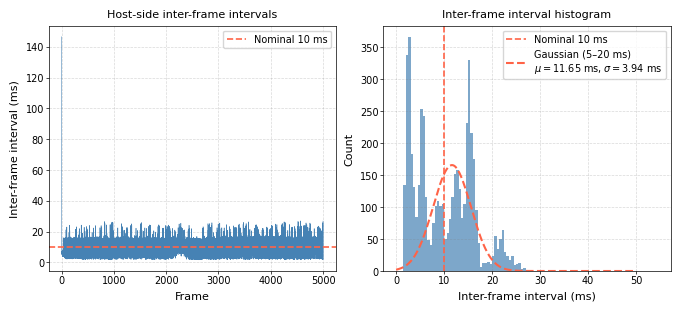

Inter-frame interval statistics (frames 1–4999)
  Mean         : 10.070 ms  (nominal 10.0 ms)
  Std          : 6.365 ms
  Median       : 9.672 ms
  Min / Max    : 1.65 / 146.40 ms
  Burst (<5 ms): 1371 frames  (27.4%)
  Late (>20 ms): 359 frames  (7.2%)

Gaussian fit to 5–20 ms window (3269 frames)
  μ = 11.649 ms,  σ = 3.941 ms


In [7]:
delta_us   = ts["delta_pop_us"].iloc[1:].values.astype(float)  # skip frame-0 ramp-up
frames_1n  = ts["frame"].iloc[1:].values
nominal_us = nominal_frame_ms * 1_000.0

# Gaussian fit restricted to the 5–20 ms window (single-frame deliveries)
mask_central = (delta_us > 5_000) & (delta_us < 20_000)
mu_g, sigma_g = stats.norm.fit(delta_us[mask_central])

fig, axs = plotter.two_column_plot(nrows=1, ncols=2)

plotter.line_plot(
    axs[0], frames_1n, delta_us / 1_000.0,
    xlabel="Frame", ylabel="Inter-frame interval (ms)",
    color="steelblue", linewidth=0.4,
)
axs[0].axhline(
    nominal_us / 1_000.0, color="tomato", linewidth=1.2,
    linestyle="--", label=f"Nominal {nominal_frame_ms:.0f} ms",
)
axs[0].legend(fontsize=7)
axs[0].set_title("Host-side inter-frame intervals", fontsize=8)

bin_edges = np.arange(0, 55, 0.5)
bin_width = float(bin_edges[1] - bin_edges[0])
plotter.histogram_plot(
    axs[1], delta_us / 1_000.0,
    bins=bin_edges,
    xlabel="Inter-frame interval (ms)", ylabel="Count",
    color="steelblue", edgecolor=None, alpha=0.7,
)
axs[1].axvline(
    nominal_us / 1_000.0, color="tomato", linewidth=1.2,
    linestyle="--", label=f"Nominal {nominal_frame_ms:.0f} ms",
)
x_g = np.linspace(0, 50, 500)
axs[1].plot(
    x_g,
    stats.norm.pdf(x_g, mu_g / 1_000.0, sigma_g / 1_000.0)
    * mask_central.sum() * bin_width,
    color="tomato", linewidth=1.5, linestyle="--",
    label=(
        f"Gaussian (5\u201320 ms)\n"
        f"$\\mu$\u2009=\u2009{mu_g/1000:.2f} ms,\u2009"
        f"$\\sigma$\u2009=\u2009{sigma_g/1000:.2f} ms"
    ),
)
axs[1].legend(fontsize=7)
axs[1].set_title("Inter-frame interval histogram", fontsize=8)

plotter.save_or_show(fig)

n_burst = int((delta_us < 5_000).sum())
n_late  = int((delta_us > 20_000).sum())
n_total = len(delta_us)
print(f"Inter-frame interval statistics (frames 1\u2013{len(ts)-1})")
print(f"  Mean         : {delta_us.mean()/1000:.3f} ms  (nominal {nominal_frame_ms:.1f} ms)")
print(f"  Std          : {delta_us.std()/1000:.3f} ms")
print(f"  Median       : {np.median(delta_us)/1000:.3f} ms")
print(f"  Min / Max    : {delta_us.min()/1000:.2f} / {delta_us.max()/1000:.2f} ms")
print(f"  Burst (<5 ms): {n_burst} frames  ({n_burst/n_total*100:.1f}%)")
print(f"  Late (>20 ms): {n_late} frames  ({n_late/n_total*100:.1f}%)")
print(f"\nGaussian fit to 5\u201320 ms window ({mask_central.sum()} frames)")
print(f"  \u03bc = {mu_g/1000:.3f} ms,  \u03c3 = {sigma_g/1000:.3f} ms")

## 4. Camera clock vs host clock

`camera_elapsed_ms` increments by the nominal frame period each frame (camera-side clock).  
`t_pop_us` is when the host PC received the frame.  
Their difference — after removing a fixed offset — shows how far ahead the camera runs
relative to the host's processing pipeline, and a linear fit to `camera_elapsed_ms`
gives the effective frame period.

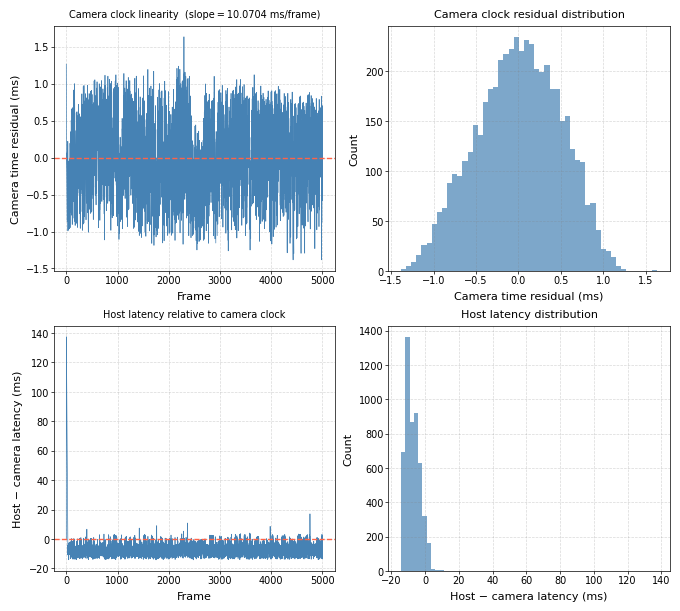

Effective frame period from camera clock: 10.0704 ms/frame
  Nominal: 10.0 ms/frame
  Deviation: 0.704 %

Camera clock residuals
  Std: 0.494 ms

Host latency relative to camera clock (offset-corrected)
  Mean : -6.81 ms
  Std  : 8.06 ms
  Min  : -14.19 ms
  Max  : 137.41 ms


In [8]:
t_pop_ms   = ts["t_pop_us"].values / 1_000.0
t_cam_ms   = ts["camera_elapsed_ms"].values
frames_all = ts["frame"].values

cam_coeffs         = np.polyfit(frames_all, t_cam_ms, 1)
effective_frame_ms = cam_coeffs[0]
cam_fit_ms         = np.polyval(cam_coeffs, frames_all)
cam_residuals_ms   = t_cam_ms - cam_fit_ms

# Host latency: how far behind (or ahead) the host pop time is vs. the camera clock.
# Subtract the frame-0 offset so zero means "host is keeping up perfectly".
latency_ms = t_pop_ms - t_cam_ms - (t_pop_ms[0] - t_cam_ms[0])

fig, axs = plotter.two_column_plot(nrows=2, ncols=2)

plotter.line_plot(
    axs[0, 0], frames_all, cam_residuals_ms,
    xlabel="Frame", ylabel="Camera time residual (ms)",
    color="steelblue", linewidth=0.5,
)
axs[0, 0].axhline(0, color="tomato", linewidth=1.0, linestyle="--")
axs[0, 0].set_title(
    f"Camera clock linearity  (slope\u2009=\u2009{effective_frame_ms:.4f} ms/frame)",
    fontsize=7,
)

plotter.histogram_plot(
    axs[0, 1], cam_residuals_ms,
    bins=50,
    xlabel="Camera time residual (ms)", ylabel="Count",
    color="steelblue", edgecolor=None, alpha=0.7,
)
axs[0, 1].set_title("Camera clock residual distribution", fontsize=8)

plotter.line_plot(
    axs[1, 0], frames_all, latency_ms,
    xlabel="Frame", ylabel="Host \u2212 camera latency (ms)",
    color="steelblue", linewidth=0.5,
)
axs[1, 0].axhline(0, color="tomato", linewidth=1.0, linestyle="--")
axs[1, 0].set_title("Host latency relative to camera clock", fontsize=7)

plotter.histogram_plot(
    axs[1, 1], latency_ms,
    bins=60,
    xlabel="Host \u2212 camera latency (ms)", ylabel="Count",
    color="steelblue", edgecolor=None, alpha=0.7,
)
axs[1, 1].set_title("Host latency distribution", fontsize=8)

plotter.save_or_show(fig)

print(f"Effective frame period from camera clock: {effective_frame_ms:.4f} ms/frame")
print(f"  Nominal: {nominal_frame_ms:.1f} ms/frame")
print(f"  Deviation: {(effective_frame_ms - nominal_frame_ms) / nominal_frame_ms * 100:.3f} %")
print(f"\nCamera clock residuals")
print(f"  Std: {cam_residuals_ms.std():.3f} ms")
print(f"\nHost latency relative to camera clock (offset-corrected)")
print(f"  Mean : {latency_ms.mean():.2f} ms")
print(f"  Std  : {latency_ms.std():.2f} ms")
print(f"  Min  : {latency_ms.min():.2f} ms")
print(f"  Max  : {latency_ms.max():.2f} ms")

## 5. Save latency

`t_saved_us \u2212 t_pop_us` is the time between the host receiving a frame and writing it
to the MMStack file.  This should be short and roughly constant; a correlation with
`circ_remaining` would indicate that buffer pressure slows disk writes.

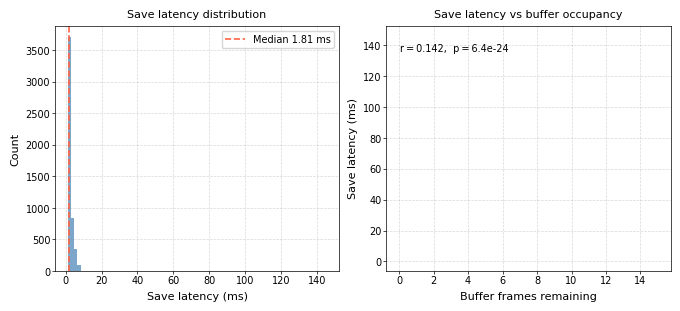

Save latency (t_saved − t_pop)
  Mean   : 2.49 ms
  Std    : 2.63 ms
  Median : 1.81 ms
  Max    : 145.42 ms

Correlation with buffer remaining: r = 0.142, p = 6.4e-24


In [9]:
save_latency_ms = (ts["t_saved_us"].values - ts["t_pop_us"].values) / 1_000.0
circ = ts["circ_remaining"].values

fig, axs = plotter.two_column_plot(nrows=1, ncols=2)

plotter.histogram_plot(
    axs[0], save_latency_ms,
    bins=80,
    xlabel="Save latency (ms)", ylabel="Count",
    color="steelblue", edgecolor=None, alpha=0.7,
)
axs[0].axvline(
    np.median(save_latency_ms), color="tomato",
    linewidth=1.2, linestyle="--",
    label=f"Median {np.median(save_latency_ms):.2f} ms",
)
axs[0].legend(fontsize=7)
axs[0].set_title("Save latency distribution", fontsize=8)

plotter.scatter_plot(
    axs[1], circ.astype(float), save_latency_ms,
    xlabel="Buffer frames remaining", ylabel="Save latency (ms)",
    color="steelblue", edgecolor="none",
    size=4, alpha=0.3, rasterized=True,
)
axs[1].set_title("Save latency vs buffer occupancy", fontsize=8)

r, p = stats.pearsonr(circ, save_latency_ms)
axs[1].text(
    0.05, 0.93, f"r\u2009=\u2009{r:.3f},  p\u2009=\u2009{p:.2g}",
    transform=axs[1].transAxes, fontsize=7, va="top",
)

plotter.save_or_show(fig)

print(f"Save latency (t_saved \u2212 t_pop)")
print(f"  Mean   : {save_latency_ms.mean():.2f} ms")
print(f"  Std    : {save_latency_ms.std():.2f} ms")
print(f"  Median : {np.median(save_latency_ms):.2f} ms")
print(f"  Max    : {save_latency_ms.max():.2f} ms")
print(f"\nCorrelation with buffer remaining: r\u2009=\u2009{r:.3f}, p\u2009=\u2009{p:.2g}")

## 6. Summary

In [10]:
summary = {
    "Dataset"                               : folder_name,
    "Total frames"                           : len(ts),
    "Total duration (s)"                     : f"{t_cam_ms[-1]/1000:.2f}",
    "Nominal frame period (ms)"              : f"{nominal_frame_ms:.1f}",
    "Effective frame period (ms)"            : f"{effective_frame_ms:.4f}",
    "Frame period deviation (%)"             : f"{(effective_frame_ms-nominal_frame_ms)/nominal_frame_ms*100:.3f}",
    "Fitted signal frequency (Hz)"           : f"{f_fit:.6f} ± {perr[1]:.6f}",
    "Frequency error (%)"                    : f"{abs(f_fit-freq_hz)/freq_hz*100:.4f}",
    "Half-amplitude A (×10⁶ counts)"        : f"{A_fit*1e-6:.3f}",
    "Saturation ceiling (×10⁶ counts)"      : f"{clip_fit*1e-6:.3f}",
    "Predicted trough (×10⁶ counts)"        : f"{(offset_fit-A_fit)*1e-6:.3f}",
    "Flat-top fraction of period"            : f"{fitted_flat_frac:.3f}",
    "Fit residual std (% amplitude)"         : f"{residuals.std()/abs(A_fit)*100:.2f}",
    "Host interval mean (ms)"                : f"{delta_us.mean()/1000:.3f}",
    "Host interval std (ms)"                 : f"{delta_us.std()/1000:.3f}",
    "Gaussian jitter σ (ms) [5–20 ms]"   : f"{sigma_g/1000:.3f}",
    "Burst frames (<5 ms) (%)"               : f"{n_burst/len(delta_us)*100:.1f}",
    "Late frames (>20 ms) (%)"               : f"{n_late/len(delta_us)*100:.1f}",
    "Save latency mean (ms)"                 : f"{save_latency_ms.mean():.2f}",
    "Save latency max (ms)"                  : f"{save_latency_ms.max():.2f}",
}

df_summary = pd.DataFrame.from_dict(summary, orient="index", columns=["Value"])
df_summary.index.name = "Metric"
display(df_summary)

,Value
Metric,
Dataset,1HzTri_10ms_512x512px
Total frames,5000
Total duration (s),50.40
Nominal frame period (ms),10.0
Effective frame period (ms),10.0704
Frame period deviation (%),0.704
Fitted signal frequency (Hz),0.999981 ± 0.000002
Frequency error (%),0.0019
Half-amplitude A (×10⁶ counts),46.786
